In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import spikeinterface as si
import spikeinterface.extractors as se
import cmap

from tools.io import load_units_metadata, load_probe

data_path = Path(r"R:\Basic_Sciences\Phys\SenzaiLab\Elissa_Belluccini\Kilosort\Mouse10_20260210_795to2220")
data_path = data_path / 'ProbeA'
output_path = Path("D:/common_datasets/gamma")

fs = 30000

plt.style.use('dark_background')
heatmap = cmap.Colormap('seaborn:vlag').to_matplotlib()

units = load_units_metadata(data_path / 'kilosort')
probe = load_probe(data_path / 'kilosort')


def plot_shank_templates(
    template: np.ndarray,
    probe: pd.DataFrame,
    title: str,
    output_path: str | Path | None = None,
    ms_before: float = 1.0,
    ms_after: float = 2.0,
    heatmap: str = 'viridis'
    ):

    fig, axs = plt.subplots(2, 5, figsize=(20, 5), sharex=False, sharey=False,
                            gridspec_kw={'height_ratios': [1, 0.05], 'wspace': 0.4, 'hspace': 0.4}
                            )
    fig.suptitle(f'Unit {unit_idx}')
    shanks = np.unique(probe['shank_ids']).astype(int)
    
    for shank in shanks: # 4 shanks
        shank_mask = probe['shank_ids'] == shank
        shank_sorted_idx = probe[shank_mask].index.values
        depths = probe[shank_mask]['depth'].values
        
        axs[0, shank].set_title(f'Shank {shank}')
        im = axs[0, shank].imshow(
                template[:, shank_sorted_idx].T,
                aspect='auto',
                origin='lower',
                interpolation='none',
                cmap=heatmap,
                extent=[-ms_before, ms_after, depths[0], depths[-1]]
            )
        axs[0, shank].axvline(0, color='green', linestyle='--', alpha=0.5, linewidth=0.6)
        fig.colorbar(im, cax=axs[1, shank], orientation='horizontal')
    
    axs[0, 4].set_title('All channels (Shank-wise depth sorted)')
    im = axs[0, 4].imshow(template[:, probe.index.values].T, aspect='auto', origin='lower', interpolation='none', cmap=heatmap, extent=[-ms_before, ms_after, 0, 384])
    axs[0, 4].axvline(0, color='green', linestyle='--', alpha=0.5, linewidth=0.6)
    fig.colorbar(im, cax=axs[1, 4], orientation='horizontal')

    if output_path:
        plt.savefig(output_path, dpi=320)
    
    plt.close(fig)

Sorting analyzer

In [2]:
processing_dir = output_path / 'postprocess'
if processing_dir.exists():
    pp = si.load_sorting_analyzer(processing_dir)
else:
    rec = si.load(str(data_path / 'concat'))
    sorting = se.read_kilosort(data_path / 'kilosort').select_units(units['cluster_id'].values)
    pp = si.create_sorting_analyzer(
        sorting=sorting,
        recording=rec,
        sparse=False,
        folder=output_path / 'postprocess',
        format='binary_folder',
        overwrite=False,
    )

    job_kwargs = dict(n_jobs=-1, chunk_duration="2s", progress_bar=True)

    compute_dict = {
        'random_spikes': {'method': 'uniform', 'max_spikes_per_unit': 5000},
        'templates': {'operators': ["average", "std"]}
    }

    pp.compute(compute_dict, **job_kwargs)

template_ext = pp.get_extension('templates')

ms_before = template_ext.params['ms_before']
ms_after = template_ext.params['ms_after']
templates = template_ext.get_templates()

Unit positions

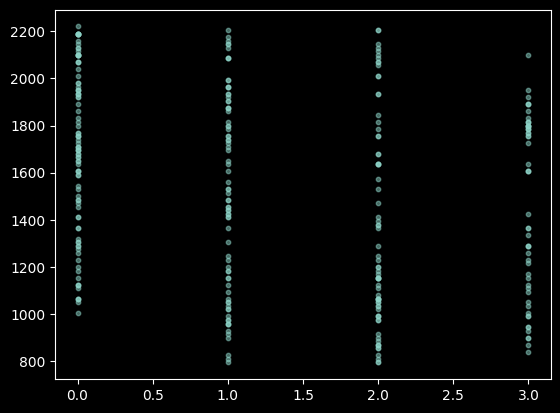

In [3]:
plt.scatter(units['shank_ids'], units['depth'], s=10, alpha=0.5)

Template analysis

In [4]:
results_dir = output_path / 'templates'
results_dir.mkdir(exist_ok=True, parents=True)

In [5]:
for idx, unit_row in units.iterrows():
    unit_id = unit_row['cluster_id']
    template = template_ext.get_unit_template(unit_id)
    template = template - template.mean(axis=0)
    break
    plot_shank_templates(template, probe, unit_id, output_path=results_dir / f'unit_{unit_id}_template.png', heatmap=heatmap)